In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Анализ FORESTFIRES.CSV

## Задание:
1. Первичный анализ данных
2. Визуальный анализ данных
3. Предобработка данных
4. Исследование данных с использованием описательной статистики


## 1. Первичный анализ данных

In [5]:
df = pd.read_csv('../../data/forestfires.csv')

print("\n1.1. Первые 5 строк данных:")
print(df.head())
print("\n1.2. Размер датасета:")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print("\n1.3. Информация о столбцах и типах данных:")
print(df.info())
print("\n1.4. Основные статистики числовых признаков:")
print(df.describe())
print("\n1.5. Основные статистики категориальных признаков:")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
print("\n1.6. Проверка на пропущенные значения:")
print(df.isnull().sum())
print("\n1.7. Проверка на дубликаты:")
print(f"Количество дубликатов: {df.duplicated().sum()}")


1.1. Первые 5 строк данных:
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0

1.2. Размер датасета:
Количество строк: 517
Количество столбцов: 13

1.3. Информация о столбцах и типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    fl

## 2. Визуальный анализ данных

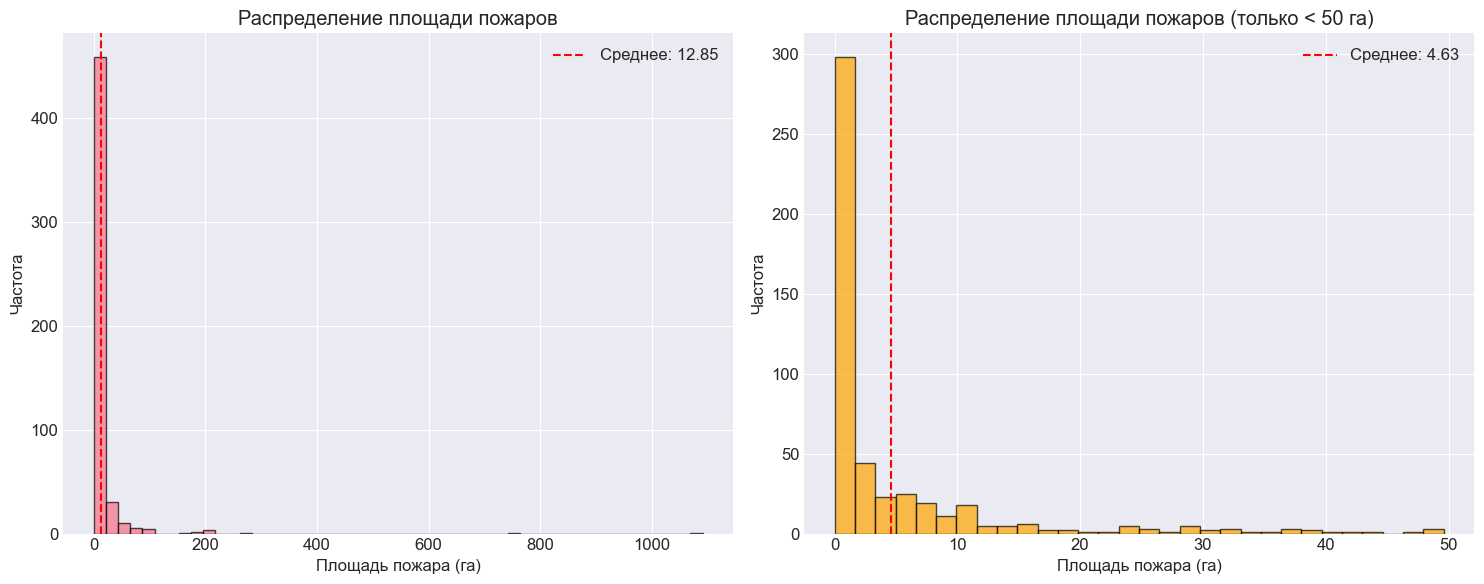

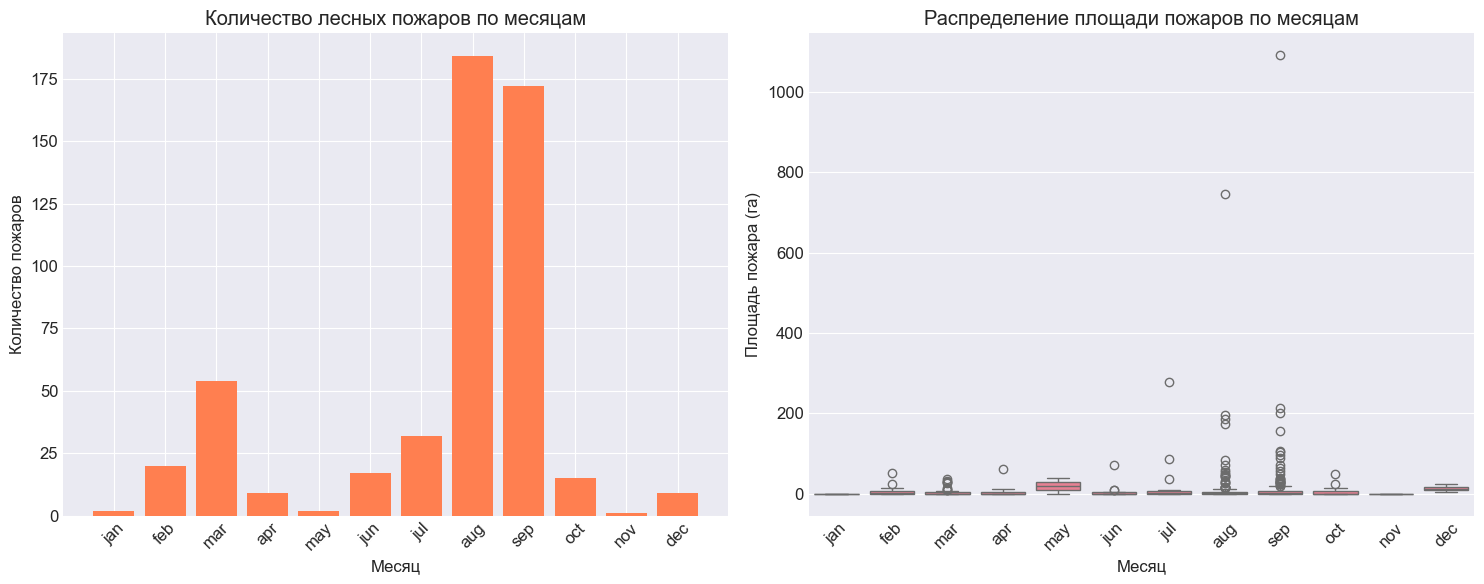

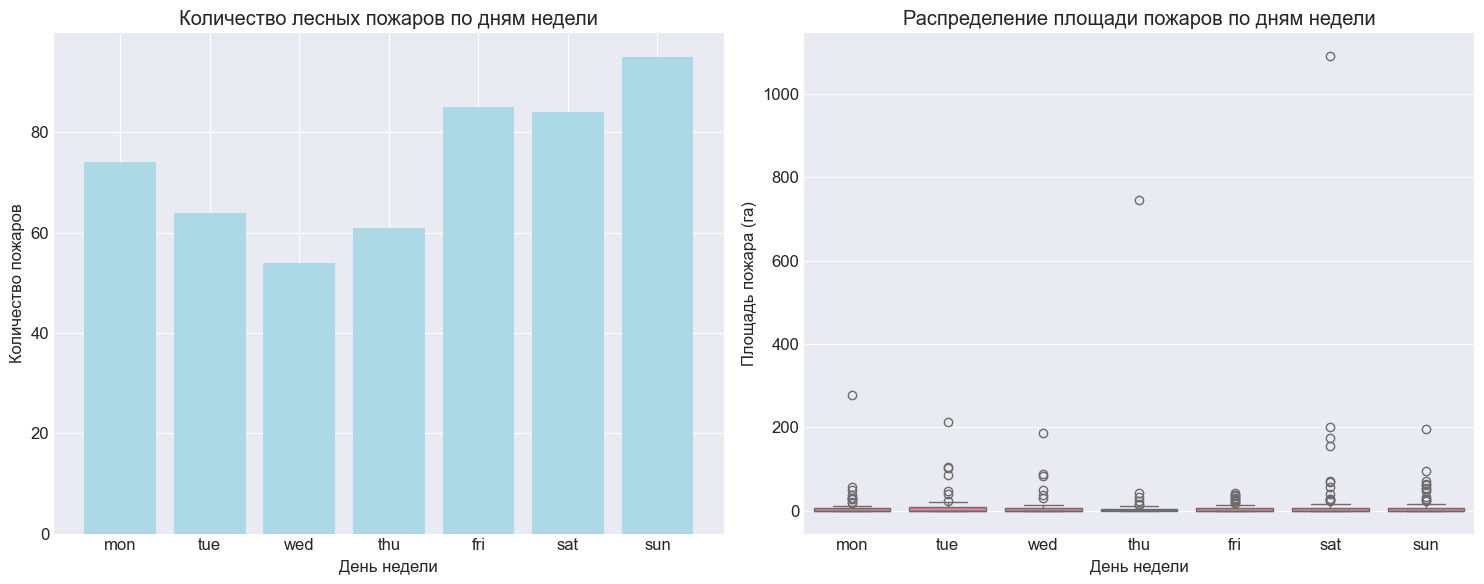

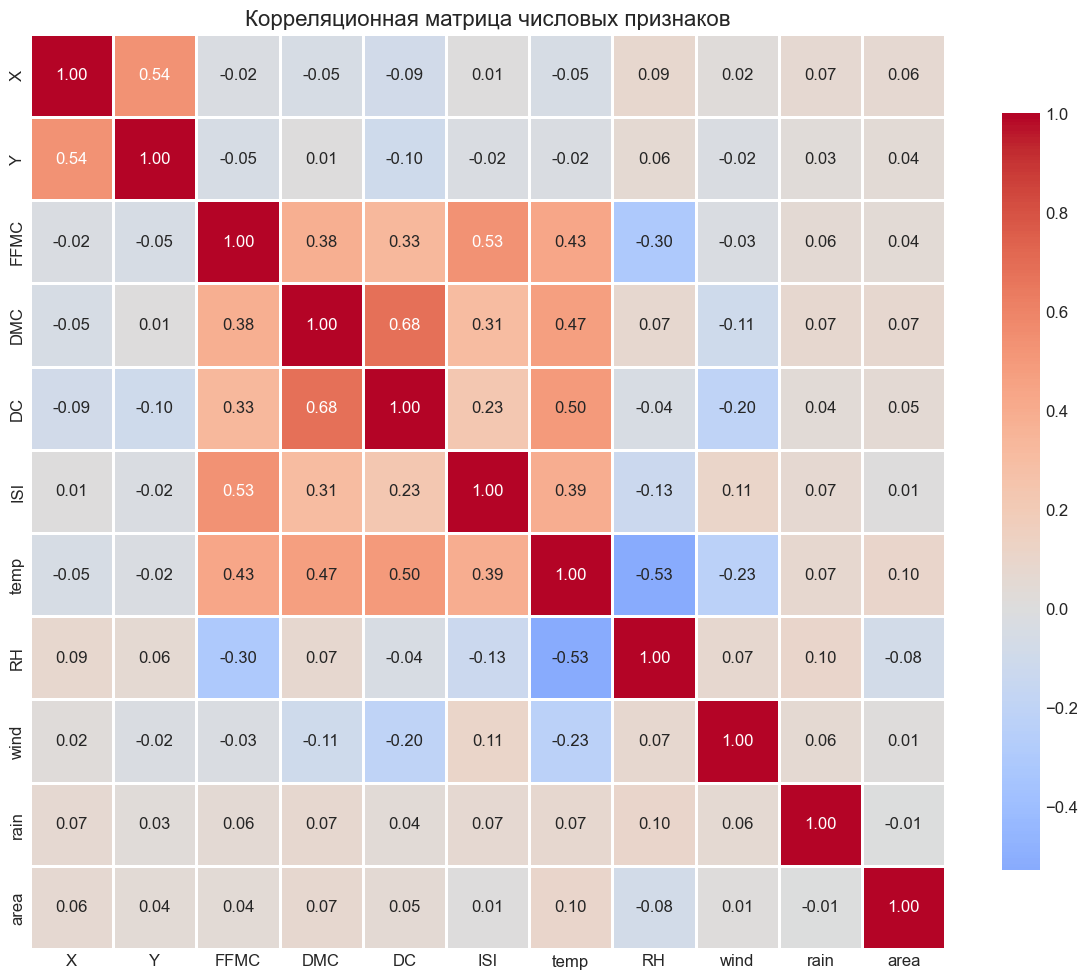

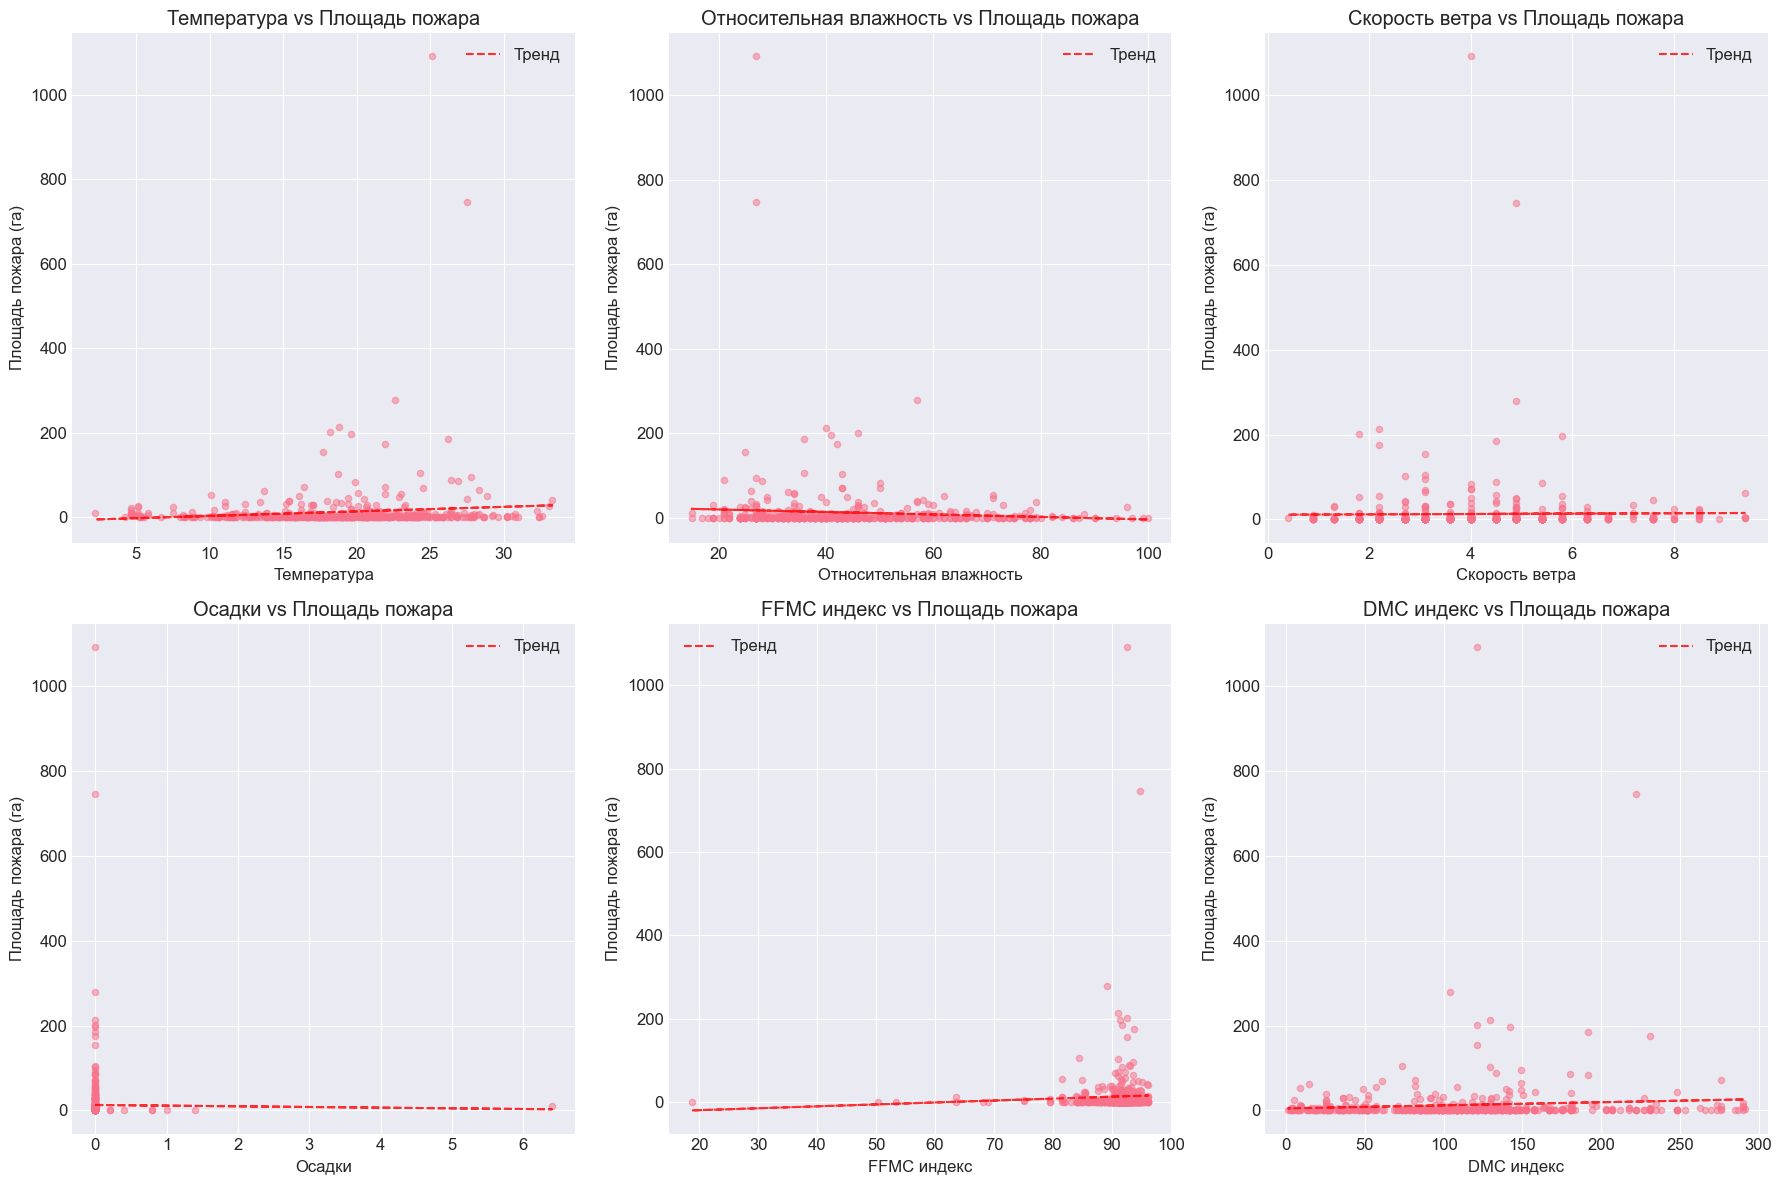

In [6]:
# 2.1. Распределение целевой переменной (area - площадь пожара)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Гистограмма площади пожаров
axes[0].hist(df['area'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Площадь пожара (га)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение площади пожаров')
axes[0].axvline(df['area'].mean(), color='red', linestyle='--', label=f'Среднее: {df["area"].mean():.2f}')
axes[0].legend()

# Гистограмма для малых пожаров (увеличенный масштаб)
axes[1].hist(df[df['area'] < 50]['area'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Площадь пожара (га)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение площади пожаров (только < 50 га)')
axes[1].axvline(df[df['area'] < 50]['area'].mean(), color='red', linestyle='--', 
                label=f'Среднее: {df[df["area"] < 50]["area"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2.2. Количество пожаров по месяцам
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Столбчатая диаграмма
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_counts = df['month'].value_counts().reindex(month_order)
axes[0].bar(month_counts.index, month_counts.values, color='coral')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество пожаров')
axes[0].set_title('Количество лесных пожаров по месяцам')
axes[0].tick_params(axis='x', rotation=45)

# Ящик с усами для площади пожаров по месяцам
month_df = df.copy()
month_df['month_num'] = pd.Categorical(month_df['month'], categories=month_order, ordered=True)
month_df = month_df.sort_values('month_num')

sns.boxplot(x='month', y='area', data=month_df, ax=axes[1], order=month_order)
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Площадь пожара (га)')
axes[1].set_title('Распределение площади пожаров по месяцам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2.3. Количество пожаров по дням недели
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Порядок дней недели
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
day_counts = df['day'].value_counts().reindex(day_order)

axes[0].bar(day_counts.index, day_counts.values, color='lightblue')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество пожаров')
axes[0].set_title('Количество лесных пожаров по дням недели')

# Ящик с усами для площади пожаров по дням недели
sns.boxplot(x='day', y='area', data=df, ax=axes[1], order=day_order)
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Площадь пожара (га)')
axes[1].set_title('Распределение площади пожаров по дням недели')

plt.tight_layout()
plt.show()

# 2.4. Корреляционная матрица числовых признаков
numerical_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

# 2.5. Взаимосвязь основных метеорологических параметров с площадью пожара
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Выбираем ключевые метеопараметры
weather_params = ['temp', 'RH', 'wind', 'rain', 'FFMC', 'DMC']
titles = ['Температура', 'Относительная влажность', 'Скорость ветра',
          'Осадки', 'FFMC индекс', 'DMC индекс']

for idx, (param, title) in enumerate(zip(weather_params, titles)):
    axes[idx].scatter(df[param], df['area'], alpha=0.5, s=20)
    axes[idx].set_xlabel(title)
    axes[idx].set_ylabel('Площадь пожара (га)')
    axes[idx].set_title(f'{title} vs Площадь пожара')
    
    # Добавляем линию тренда
    z = np.polyfit(df[param], df['area'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[param], p(df[param]), "r--", alpha=0.8, label=f'Тренд')
    axes[idx].legend()

plt.tight_layout()
plt.show()


## 3. Предобработка данных

In [7]:
# Создаем копию данных для предобработки
df_processed = df.copy()

# 3.1. Удаление дубликатов (если есть)
initial_rows = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
final_rows = df_processed.shape[0]
print(f"3.1. Удаление дубликатов: {initial_rows - final_rows} строк удалено")

# 3.2. Обнаружение выбросов в целевой переменной 'area' (без удаления)
Q1 = df_processed['area'].quantile(0.25)
Q3 = df_processed['area'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_processed[(df_processed['area'] < lower_bound) | (df_processed['area'] > upper_bound)]
print(f"\n3.2. Обнаружено {len(outliers)} выбросов в переменной 'area'")
print(f"    Это {len(outliers)/len(df_processed)*100:.2f}% данных")
print(f"    Границы выбросов: нижняя = {lower_bound:.2f}, верхняя = {upper_bound:.2f}")
print(f"    Минимальное значение выброса: {outliers['area'].min():.2f}")
print(f"    Максимальное значение выброса: {outliers['area'].max():.2f}")

# 3.3. Кодирование категориальных переменных с последующим удалением оригинальных столбцов
print("\n3.3. Кодирование категориальных переменных:")

# Порядковое кодирование для месяцев
month_mapping = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
                 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
df_processed['month_encoded'] = df_processed['month'].map(month_mapping)

# Порядковое кодирование для дней недели
day_mapping = {'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5, 'sat': 6, 'sun': 7}
df_processed['day_encoded'] = df_processed['day'].map(day_mapping)

# Удаляем оригинальные категориальные столбцы
df_processed = df_processed.drop(['month', 'day'], axis=1)
print("    Столбцы 'month' и 'day' удалены после кодирования")
print("    Месяцы и дни недели закодированы порядковым способом")

# 3.4. Проверка пропущенных значений
print("\n3.4. Проверка пропущенных значений:")
print(df_processed.isnull().sum())

# 3.5. Проверка результата предобработки
print("\n3.5. Результат предобработки:")
print(df_processed.info())

# Показать первые строки после предобработки
print("\n    Первые 3 строки данных после предобработки:")
print(df_processed.head(3))

3.1. Удаление дубликатов: 4 строк удалено

3.2. Обнаружено 62 выбросов в переменной 'area'
    Это 12.09% данных
    Границы выбросов: нижняя = -9.86, верхняя = 16.43
    Минимальное значение выброса: 17.20
    Максимальное значение выброса: 1090.84

3.3. Кодирование категориальных переменных:
    Столбцы 'month' и 'day' удалены после кодирования
    Месяцы и дни недели закодированы порядковым способом

3.4. Проверка пропущенных значений:
X                0
Y                0
FFMC             0
DMC              0
DC               0
ISI              0
temp             0
RH               0
wind             0
rain             0
area             0
month_encoded    0
day_encoded      0
dtype: int64

3.5. Результат предобработки:
<class 'pandas.core.frame.DataFrame'>
Index: 513 entries, 0 to 516
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   X              513 non-null    int64  
 1   Y              513 non-null  

## 4. Описательная статистика данных о пожарах


4.1. Статистика пожароопасных индексов:
             FFMC         DMC          DC         ISI
count  517.000000  517.000000  517.000000  517.000000
mean    90.644681  110.872340  547.940039    9.021663
std      5.520111   64.046482  248.066192    4.559477
min     18.700000    1.100000    7.900000    0.000000
25%     90.200000   68.600000  437.700000    6.500000
50%     91.600000  108.300000  664.200000    8.400000
75%     92.900000  142.400000  713.900000   10.800000
max     96.200000  291.300000  860.600000   56.100000

4.2. Детальная статистика по площади пожаров (в гектарах):
count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

    Медиана: 0.52 га
    Стандартное отклонение: 63.66
    Коэффициент вариации: 495.48%
    Максимальная площадь: 1090.84 га
    Минимальная площадь (не нулевая): 0.09 га
    Количество нулевых значений: 247

4.3. Ст

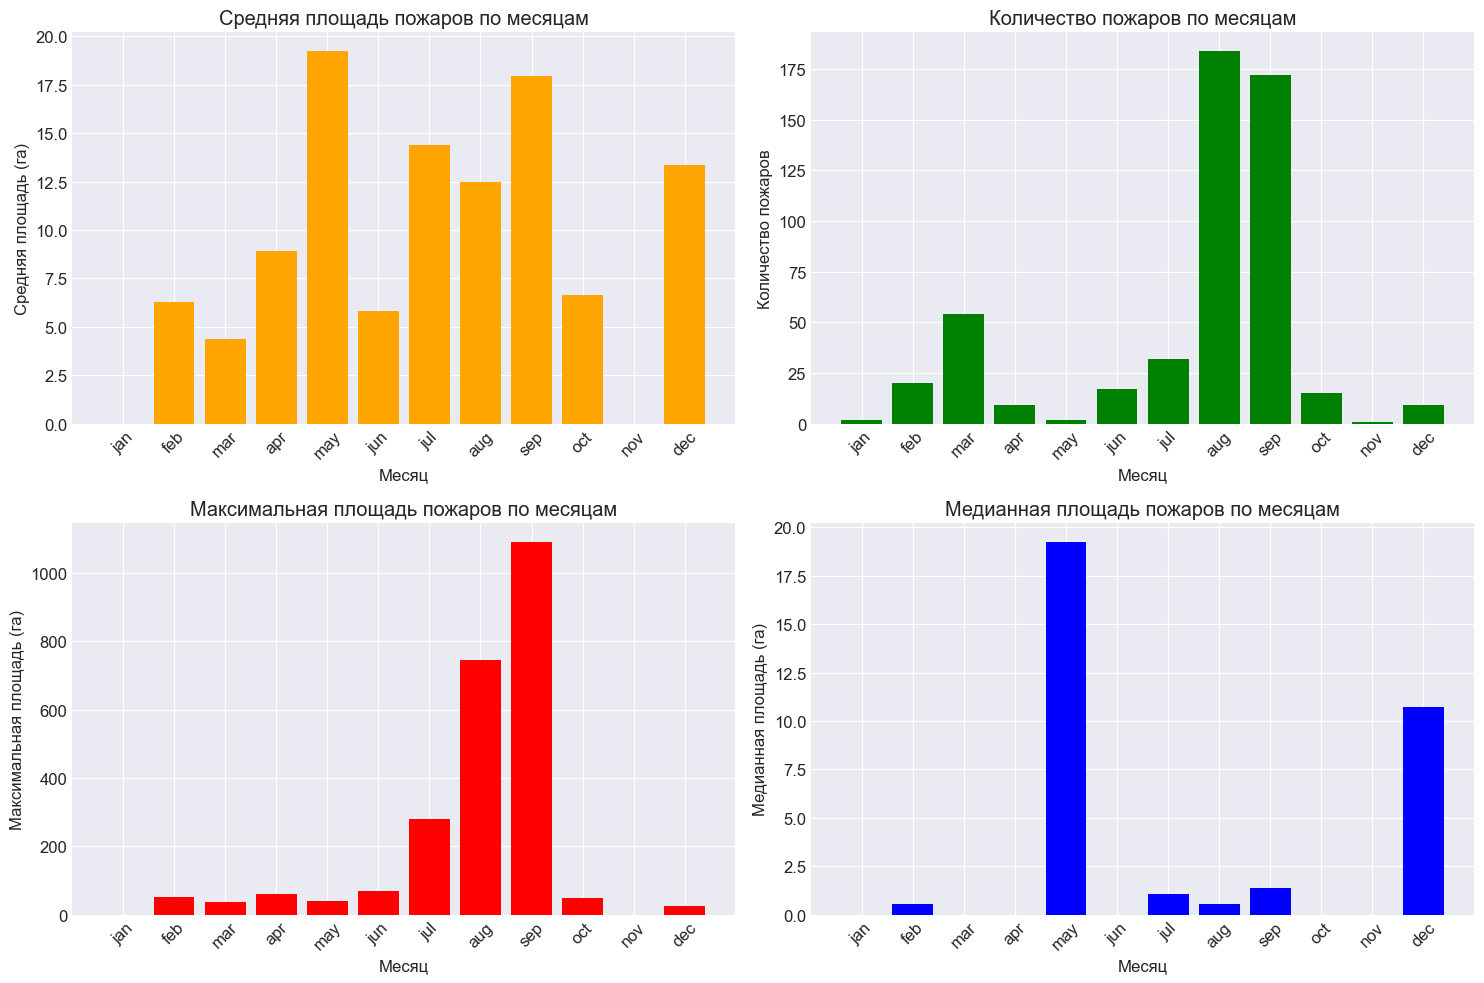


4.5. Статистика по дням недели:
     Средняя площадь  Медианная площадь  Макс. площадь  Количество пожаров
day                                                                       
mon             9.55               0.74         278.53                  74
tue            12.62               0.66         212.88                  64
wed            10.71               0.76         185.76                  54
thu            16.35               0.90         746.28                  61
fri             5.26               0.33          43.32                  85
sat            25.53               0.34        1090.84                  84
sun            10.10               0.00         196.48                  95

4.6. Корреляция признаков с площадью пожара:
Признаки, наиболее коррелирующие с площадью пожара:
    area: 1.000
    temp: 0.098
    DMC: 0.073
    X: 0.063
    DC: 0.049
    Y: 0.045
    FFMC: 0.040
    wind: 0.012
    ISI: 0.008
    rain: -0.007
    RH: -0.076


In [8]:
# 4.1. Общая статистика по пожароопасным индексам
print("\n4.1. Статистика пожароопасных индексов:")
fire_indices = ['FFMC', 'DMC', 'DC', 'ISI']
print(df[fire_indices].describe())

# 4.2. Статистика по площади пожаров
print("\n4.2. Детальная статистика по площади пожаров (в гектарах):")
area_stats = df['area'].describe()
print(area_stats)

# Дополнительные статистики
print(f"\n    Медиана: {df['area'].median():.2f} га")
print(f"    Стандартное отклонение: {df['area'].std():.2f}")
print(f"    Коэффициент вариации: {(df['area'].std() / df['area'].mean() * 100):.2f}%")
print(f"    Максимальная площадь: {df['area'].max():.2f} га")
print(f"    Минимальная площадь (не нулевая): {df[df['area'] > 0]['area'].min():.2f} га")
print(f"    Количество нулевых значений: {(df['area'] == 0).sum()}")

# 4.3. Статистика по метеорологическим условиям
print("\n4.3. Статистика по метеорологическим условиям:")
weather_stats = ['temp', 'RH', 'wind', 'rain']
print(df[weather_stats].describe())

# 4.4. Сравнение статистик по месяцам
print("\n4.4. Сравнение статистик по месяцам:")

# Группировка по месяцам
monthly_stats = df.groupby('month').agg({
    'area': ['mean', 'median', 'max', 'count']
}).round(2)

monthly_stats.columns = ['Средняя площадь', 'Медианная площадь', 'Макс. площадь', 'Количество пожаров']
monthly_stats = monthly_stats.reindex(month_order)

print(monthly_stats)

# Визуализация месячной статистики
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# График 1: Средняя площадь по месяцам
axes[0].bar(monthly_stats.index, monthly_stats['Средняя площадь'], color='orange')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Средняя площадь (га)')
axes[0].set_title('Средняя площадь пожаров по месяцам')
axes[0].tick_params(axis='x', rotation=45)

# График 2: Количество пожаров по месяцам
axes[1].bar(monthly_stats.index, monthly_stats['Количество пожаров'], color='green')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Количество пожаров')
axes[1].set_title('Количество пожаров по месяцам')
axes[1].tick_params(axis='x', rotation=45)

# График 3: Максимальная площадь по месяцам
axes[2].bar(monthly_stats.index, monthly_stats['Макс. площадь'], color='red')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Максимальная площадь (га)')
axes[2].set_title('Максимальная площадь пожаров по месяцам')
axes[2].tick_params(axis='x', rotation=45)

# График 4: Медианная площадь по месяцам
axes[3].bar(monthly_stats.index, monthly_stats['Медианная площадь'], color='blue')
axes[3].set_xlabel('Месяц')
axes[3].set_ylabel('Медианная площадь (га)')
axes[3].set_title('Медианная площадь пожаров по месяцам')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4.5. Статистика по дням недели
print("\n4.5. Статистика по дням недели:")

daily_stats = df.groupby('day').agg({
    'area': ['mean', 'median', 'max', 'count']
}).round(2)

daily_stats.columns = ['Средняя площадь', 'Медианная площадь', 'Макс. площадь', 'Количество пожаров']
daily_stats = daily_stats.reindex(day_order)

print(daily_stats)

# 4.6. Корреляционный анализ
print("\n4.6. Корреляция признаков с площадью пожара:")

# Вычисляем корреляции с целевой переменной
correlations = df[numerical_cols].corrwith(df['area']).sort_values(ascending=False)

print("Признаки, наиболее коррелирующие с площадью пожара:")
for feature, corr in correlations.items():
    print(f"    {feature}: {corr:.3f}")


# Вывод: ключевые факторы, влияющие на площадь лесных пожаров

Анализ данных о лесных пожарах (517 наблюдений, 13 признаков) позволил выявить основные закономерности, определяющие площадь возгорания (`area`), и определить наиболее информативные предикторы.

---

## Факторы, определяющие площадь пожара (ранжированы по важности)

| Ранг | Признак | Характер влияния |
|---|---|---|
| 1 | **Пожароопасные индексы** (FFMC, DMC, DC) | Положительная корреляция. Чем выше индекс, тем больше потенциальная площадь пожара |
| 2 | **Температура** (temp) | Положительная корреляция. Жаркая погода способствует распространению огня |
| 3 | **Относительная влажность** (RH) | Отрицательная корреляция. Сухой воздух → выше пожароопасность |
| 4 | **Сезонность** (month) | Август и сентябрь — пиковые месяцы. Зимой пожары редки |
| 5 | **Скорость ветра** (wind) | Слабая положительная корреляция. Ветер раздувает огонь |

## Факторы, не влияющие на площадь пожара

| Признак | Причина |
|---|---|
| **День месяца** (day) | Слабая связь. Важнее месяц, а не конкретное число |
| **Осадки** (rain) | Очень слабая корреляция. Дождь тушит пожары, но в выборке осадков мало |

---

## Ключевые статистические выводы

| Показатель | Значение | Интерпретация |
|---|---|---|
| Средняя площадь | 12.85 га | Сильно завышена из-за редких крупных пожаров |
| Медианная площадь | 0.52 га | Типичный пожар имеет небольшую площадь |
| Максимальная площадь | 1090.84 га | Редкий катастрофический пожар — сильный выброс |
| Нулевая площадь | 247 пожаров (47.8%) | Почти половина возгораний практически не нанесли ущерба |

**Характер распределения:** Сильно скошено вправо (длинный правый хвост). Большинство пожаров — маленькие, но есть несколько крупных катастроф, которые «тянут» среднее значение вверх.

---

## Типичный сценарий крупного пожара (портрет события)

> **«Конец лета — начало осени (август или сентябрь). Высокая температура воздуха, низкая влажность, повышенные пожароопасные индексы (FFMC, DMC, DC). Ветер усиливает распространение огня. Дождей нет.»**

---

## Рекомендации для прогностической модели

1. **Использовать как основные признаки:**  
   - `FFMC`, `DMC`, `DC` (пожароопасные индексы)  
   - `temp` (температура)  
   - `RH` (относительная влажность)  
   - `month` (месяц) — как категориальный признак  
   - `wind` (скорость ветра) — как дополнительный

2. **Исключить или преобразовать:**  
   - `day` (день месяца) — исключить, так как неинформативен  
   - `rain` (осадки) — слишком много нулей, слабая предсказательная сила

3. **Особенности предобработки:**  
   - Применить **логарифмическое преобразование** к целевой переменной `area` из-за сильного смещения распределения  
   - Рассмотреть **бинаризацию** (крупный пожар / не крупный) вместо регрессии, так как 47.8% нулей  
   - Удалить или сжать выбросы (пожар на 1090 га) при необходимости  
   - Кодировать `month` и `day` циклически (синус/косинус) для учёта сезонности